<a href="https://colab.research.google.com/github/AnnaZapototska/colab-code-work/blob/development/hw_task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 5
Homework for the module "Algorithms of Learning Without a Teacher"

In [19]:
!pip install category_encoders

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


## Part 1

In [21]:
!wget -O mod_05_topic_10_various_data.pkl \
https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl

--2026-09-05 16:17:57--  https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18343147 (17M) [application/octet-stream]
Saving to: ‘mod_05_topic_10_various_data.pkl’

mod_05_topic_10_var 100%[===================>]  17.49M  --.-KB/s    in 0.1s    

2026-09-05 16:17:57 (168 MB/s) - ‘mod_05_topic_10_various_data.pkl’ saved [18343147/18343147]



In [22]:
with open('mod_05_topic_10_various_data.pkl', 'rb') as fl:
    datasets = pickle.load(fl)

In [23]:
concrete = datasets['concrete']

print(concrete.head())
print(concrete.shape)
print(concrete.info())

   Cement  BlastFurnaceSlag  FlyAsh  Water  Superplasticizer  CoarseAggregate  \
0   102.0             153.0     0.0  192.0               0.0            887.0   
1   108.3             162.4     0.0  203.5               0.0            938.2   
2   116.0             173.0     0.0  192.0               0.0            909.8   
3   122.6             183.9     0.0  203.5               0.0            958.2   
4   132.0             206.5   160.9  178.9               5.5            866.9   

   FineAggregate  CompressiveStrength  
0          942.0                25.46  
1          849.0                29.23  
2          891.9                31.02  
3          800.1                33.19  
4          735.6                33.31  
(427, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cement               427 non-null    float64
 1   Blast

## Part 2

In [24]:
concrete.columns

Index(['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water', 'Superplasticizer',
       'CoarseAggregate', 'FineAggregate', 'CompressiveStrength'],
      dtype='object')

In [25]:
component_cols = [
    'Cement',
    'BlastFurnaceSlag',
    'FlyAsh',
    'Water',
    'Superplasticizer',
    'CoarseAggregate',
    'FineAggregate'
]

concrete['Components'] = (concrete[component_cols] > 0).sum(axis=1)

print(concrete.head())

   Cement  BlastFurnaceSlag  FlyAsh  Water  Superplasticizer  CoarseAggregate  \
0   102.0             153.0     0.0  192.0               0.0            887.0   
1   108.3             162.4     0.0  203.5               0.0            938.2   
2   116.0             173.0     0.0  192.0               0.0            909.8   
3   122.6             183.9     0.0  203.5               0.0            958.2   
4   132.0             206.5   160.9  178.9               5.5            866.9   

   FineAggregate  CompressiveStrength  Components  
0          942.0                25.46           5  
1          849.0                29.23           5  
2          891.9                31.02           5  
3          800.1                33.19           5  
4          735.6                33.31           7  


## Part 3

In [26]:
X = concrete.drop(columns='CompressiveStrength')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Part 4

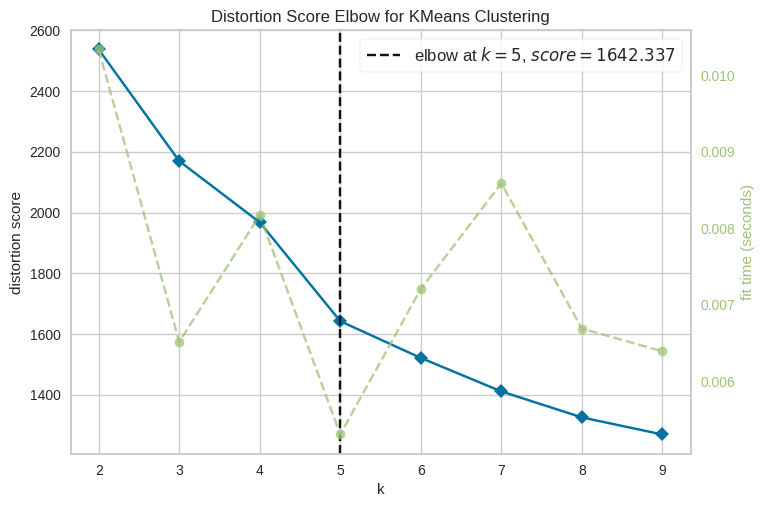

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [27]:
model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(2, 10))
visualizer.fit(X_scaled)
visualizer.show()

## Part 5

In [28]:
kmeans = KMeans(n_clusters=5, random_state=42)

labels = kmeans.fit_predict(X_scaled)

In [29]:
print(labels[:10])

[1 1 1 1 2 2 1 1 1 0]


## Part 6

In [30]:
concrete_report = concrete.copy()
concrete_report['Cluster'] = labels

In [31]:
report = concrete_report.groupby('Cluster').median()
report

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components
Cluster,,,,,,,,,
0,212.3,0.00,125.2,169.95,9.9,1002.0,795.55,39.880,6.0
1,186.2,183.40,0.0,190.00,0.0,977.0,734.30,37.430,5.0
2,193.0,119.25,116.0,193.55,8.5,879.6,744.10,33.175,7.0
3,356.0,121.00,0.0,162.00,10.0,914.3,803.70,59.000,6.0
4,342.0,0.00,0.0,186.00,0.0,1040.0,774.00,36.940,4.0


## Part 7

In [32]:
cluster_counts = concrete_report['Cluster'].value_counts().sort_index()
report['Count'] = cluster_counts
report

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components,Count
Cluster,,,,,,,,,,
0,212.3,0.00,125.2,169.95,9.9,1002.0,795.55,39.880,6.0,84
1,186.2,183.40,0.0,190.00,0.0,977.0,734.30,37.430,5.0,85
2,193.0,119.25,116.0,193.55,8.5,879.6,744.10,33.175,7.0,118
3,356.0,121.00,0.0,162.00,10.0,914.3,803.70,59.000,6.0,53
4,342.0,0.00,0.0,186.00,0.0,1040.0,774.00,36.940,4.0,87


# Summary

According to the results of clustering, 5 groups of concrete formulations were identified. The highest median strength is characterized by cluster 3 (59.0), which is characterized by a high cement content (356) and a relatively low water content (162). In contrast, the lowest median strength is characterized by cluster 2 (33.18), which has a lower cement content and a higher water content.

At the same time, the number of components does not show a direct relationship with strength: cluster 2 has the highest median number of components (7), but at the same time the lowest strength. Similarly, a high amount of cement does not guarantee high strength - cluster 4 has almost the same high cement content (342) as cluster 3, but its median strength is only 36.94. Therefore, it can be assumed that the strength of concrete is affected not by the individual amount of a certain component, but by their combination and ratio, in particular the ratio of cement to water.